<a href="https://colab.research.google.com/github/DeepaJain29/cat_vs_dog_CNN/blob/main/cat_v_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"deepajain2926","key":"5fac0d0f4481598421d885f799864a41"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d tongpython/cat-and-dog


Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 55% 119M/218M [00:00<00:00, 1.22GB/s]
100% 218M/218M [00:00<00:00, 735MB/s] 


In [ ]:
!unzip cat-and-dog.zip -d cat_dog


Streaming output truncated to the last 5000 lines.
  inflating: cat_dog/training_set/training_set/cats/cat.3704.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3705.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3706.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3707.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3708.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3709.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.371.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3710.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3711.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3712.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3713.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3714.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3715.jpg  
  inflating: cat_dog/training_set/training_set/cats/cat.3716.jpg  
  inflating:

In [ ]:
!ls cat_dog


test_set  training_set


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from keras.models import Model
import matplotlib.pyplot as plt


In [ ]:
train_ds = keras.utils.image_dataset_from_directory(directory= "cat_dog/training_set", labels="inferred", batch_size=32, image_size=(256,256), label_mode="int")
val_ds = keras.utils.image_dataset_from_directory(directory= "cat_dog/test_set", labels="inferred", batch_size=32, image_size=(256,256), label_mode="int")

Found 8005 files belonging to 1 classes.
Found 2023 files belonging to 1 classes.


In [ ]:
#Normalise
def process(image, label):
  image = tf.cast(image/255.0, tf.float32)
  return image, label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [ ]:
# Build a CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.9939 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━

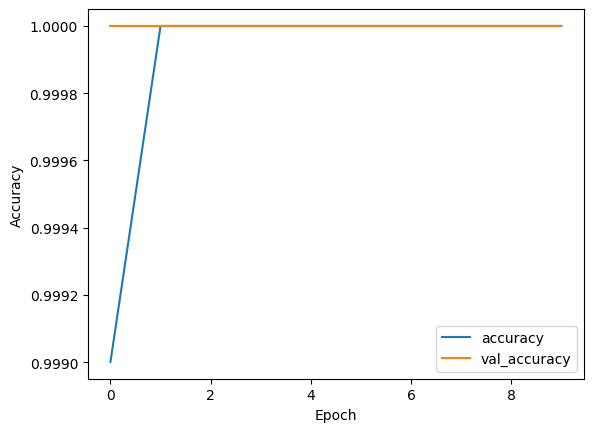

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


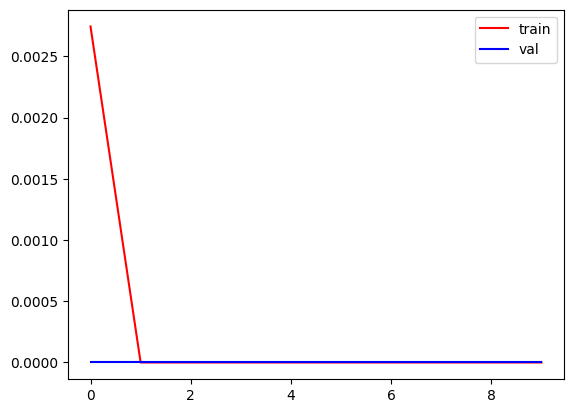

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label = 'val')
plt.legend()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()
for fn in uploaded.keys():
  img = image.load_img(fn, target_size=(256, 256))
  x = image.img_to_array(img)
  x = tf.expand_dims(x, 0)
  x /= 255.0

  prediction = model.predict(x)
  if prediction < 0.5:
    print(f"{fn} → 🐱 Cat")
  else:
    print(f"{fn} → 🐶 Dog")


In [ ]:
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator